In [1]:
import json
import math
import os
import gc
import itertools
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

2026-05-26 10:31:10.525502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779791470.769916      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779791470.845525      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779791471.451333      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779791471.451376      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779791471.451379      23 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [3]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Augmented Sub-datasets/AISSLab-v5/"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=384)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=384)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=384)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=384)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=384)

In [4]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 72
Shape: (72, 384, 384, 3)
Total images loaded: 192
Shape: (192, 384, 384, 3)
Total images loaded: 224
Shape: (224, 384, 384, 3)
Total images loaded: 176
Shape: (176, 384, 384, 3)


In [5]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [6]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# EfficientNetV2 PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=11,
    stratify=y_train
)
print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (424, 384, 384, 3)
y_train: (424,)
x_val: (107, 384, 384, 3)
y_val: (107,)
x_test: (133, 384, 384, 3)
y_test: (133,)


In [8]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Convert one-hot -> labels if needed
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Check original distribution
print("Original class distribution:")
print(Counter(y_train_labels))

# Flatten image data temporarily
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# Apply Oversampling
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# Restore image shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

# One-hot Encode Labels
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)
    
# Final Distribution
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 143, np.int64(1): 122, np.int64(3): 113, np.int64(0): 46})

Balanced class distribution:
Counter({np.int64(1): 1200, np.int64(3): 1200, np.int64(2): 1200, np.int64(0): 1200})


In [9]:
BATCH_SIZE = 8

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [10]:
IMAGE_SIZE = 384

input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
inputs = Input(shape=input_shape)

# EfficientNetV2S PREPROCESSING
efficientnet = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

I0000 00:00:1779791561.088932      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779791561.091425      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# FREEZE
for layer in efficientnet.layers:
    layer.trainable = False

In [12]:
# CLASSIFIER HEAD
x = efficientnet.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256,activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(4,activation='softmax')(x)

# FINAL MODEL
model = Model(inputs,outputs)

In [13]:
# COMPILE
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 384, 384,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 192, 192,  │        648 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 192, 192,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 192, 192,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 192, 192,  │      5,184 │ stem_activation[… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 192, 192,  │         96 │ block1a_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 192, 192,  │          0 │ block1a_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 192, 192,  │          0 │ block1a_project_… │
│                     │ 24)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 192, 192,  │      5,184 │ block1a_add[0][0] │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 192, 192,  │         96 │ block1b_project_… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 192, 192,  │          0 │ block1b_project_… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 192, 192,  │          0 │ block1b_project_… │
│ (Dropout)           │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 192, 192,  │          0 │ block1b_drop[0][… │
│                     │ 24)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 96, 96,    │     20,736 │ block1b_add[0][0] │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 96, 96,    │        384 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 96, 96,    │          0 │ block2a_expand_b

 Total params: 20,666,468 (78.84 MB)

 Trainable params: 332,036 (1.27 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

filepath="/kaggle/working/efficientnetv2s.keras"

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',  
    verbose=1,
    save_best_only=True,
    mode='max'
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',  
    patience=8,             
    verbose=1,
    mode='max',
    restore_best_weights=True
)

# LR 
learn_control = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [15]:
history = model.fit(
    train_generator.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint, early_stopping, learn_control]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1779791586.760964      75 service.cc:152] XLA service 0x784cf42695a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779791586.761003      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779791586.761008      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779791591.107699      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-26 10:33:20.168832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:33:20.308481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:33:21.147976: E external/local_xl

600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3249 - loss: 2.0107

2026-05-26 10:36:08.725838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:36:08.895585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:36:10.001318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:36:10.185026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 10:36:11.785103: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.43925, saving model to /kaggle/working/efficientnetv2s.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 229s 290ms/step - accuracy: 0.3249 - loss: 2.0104 - val_accuracy: 0.4393 - val_loss: 1.4409 - learning_rate: 1.0000e-04
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.4300 - loss: 1.5835
Epoch 2: val_accuracy improved from 0.43925 to 0.51402, saving model to /kaggle/working/efficientnetv2s.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 136s 227ms/step - accuracy: 0.4300 - loss: 1.5833 - val_accuracy: 0.5140 - val_loss: 1.2840 - learning_rate: 1.0000e-04
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.4890 - loss: 1.3264
Epoch 3: val_accuracy improved from 0.51402 to 0.52336, saving model to /kaggle/working/efficientnetv2s.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 136s 227ms/step - accuracy: 0.4890 - loss: 1.3263 - val_accuracy: 0.5234 - val_loss: 1.3216 - learning_rate: 1.0000e-04
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/

In [16]:
# UNFREEZE LAST 20 LAYERS
for layer in efficientnet.layers[-20:]:
    layer.trainable=True

In [17]:
# RECOMPILE

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history_fine = model.fit(
    train_generator.flow(
        x_train,
        y_train,
        batch_size=BATCH_SIZE
    ),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[
        checkpoint,
        early_stopping,
        learn_control
    ]
)

Epoch 1/100


2026-05-26 11:38:46.718291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 11:38:46.867741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6878 - loss: 0.7724
Epoch 1: val_accuracy did not improve from 0.75701
600/600 ━━━━━━━━━━━━━━━━━━━━ 213s 268ms/step - accuracy: 0.6878 - loss: 0.7723 - val_accuracy: 0.7477 - val_loss: 0.7674 - learning_rate: 1.0000e-04
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7541 - loss: 0.6088
Epoch 2: val_accuracy did not improve from 0.75701
600/600 ━━━━━━━━━━━━━━━━━━━━ 137s 228ms/step - accuracy: 0.7542 - loss: 0.6088 - val_accuracy: 0.7477 - val_loss: 0.6536 - learning_rate: 1.0000e-04
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8080 - loss: 0.5093
Epoch 3: val_accuracy improved from 0.75701 to 0.80374, saving model to /kaggle/working/efficientnetv2s.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 139s 232ms/step - accuracy: 0.8080 - loss: 0.5093 - val_accuracy: 0.8037 - val_loss: 0.5366 - learning_rate: 1.0000e-04
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8577 - loss: 0.41

In [19]:
y_pred = model.predict(x_test)

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step

2026-05-26 12:43:02.205662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 12:43:02.341603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 12:43:03.161045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 12:43:03.299861: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-26 12:43:04.695944: E external/local_xla/xla/stream_

5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step


Confusion matrix, without normalization
[[14  0  0  0]
 [ 2 36  1  0]
 [ 0  1 44  0]
 [ 0  0  1 34]]


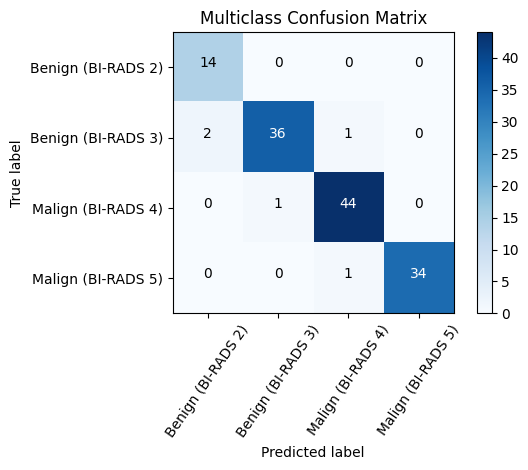

In [20]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=55)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))

cm_plot_label =['Benign (BI-RADS 2)', 'Benign (BI-RADS 3)', 'Malign (BI-RADS 4)', 'Malign (BI-RADS 5)']
plot_confusion_matrix(cm, cm_plot_label, title ='Multiclass Confusion Matrix')

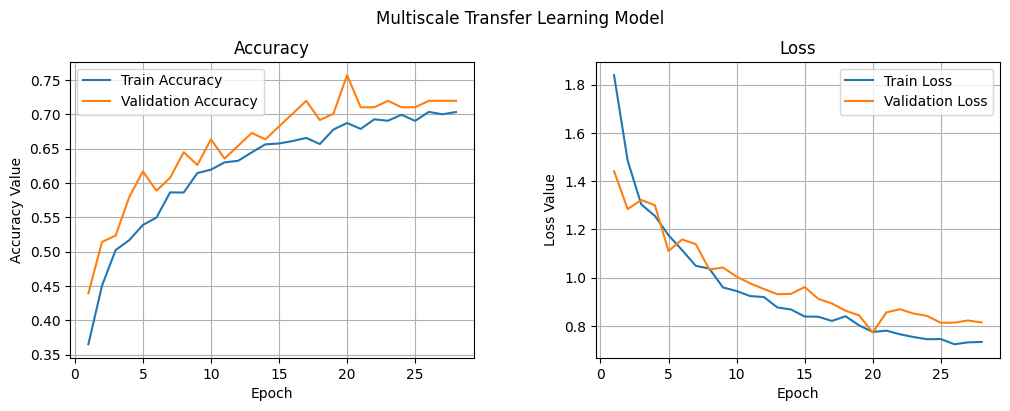

In [21]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

t = f.suptitle('Multiscale Transfer Learning Model', fontsize=12)

f.subplots_adjust(top=0.85, wspace=0.3)

# Dynamic epoch count
epoch_list = range(1, len(history.history['accuracy']) + 1)

# Accuracy Plot
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')

ax1.grid()
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

# Loss Plot
ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')

ax2.grid()
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

In [22]:
print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)

y_test: (133, 4)
y_pred: (133, 4)


In [23]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    cohen_kappa_score
)

# Predictions
pred = model.predict(x_test)
y_pred = np.argmax(pred, axis=1)
y_test = np.argmax(y_test, axis=1)

# Target labels
target_names = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Print all metrics
print("\nAdditional Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"Cohen's Kappa  : {kappa:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
Classification Report:
                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.88      1.00      0.93        14
Benign (BI-RADS 3)       0.97      0.92      0.95        39
Malign (BI-RADS 4)       0.96      0.98      0.97        45
Malign (BI-RADS 5)       1.00      0.97      0.99        35

          accuracy                           0.96       133
         macro avg       0.95      0.97      0.96       133
      weighted avg       0.96      0.96      0.96       133

Confusion Matrix:
[[14  0  0  0]
 [ 2 36  1  0]
 [ 0  1 44  0]
 [ 0  0  1 34]]

Additional Evaluation Metrics:
Accuracy       : 0.9624
Precision      : 0.9642
Recall         : 0.9624
F1-score       : 0.9626
MCC            : 0.9483
MAE            : 0.0376
MSE            : 0.0376
Cohen's Kappa  : 0.9479
